# Experiment 3: Regression on the US Airport Network

## 🎯 Objective

This experiment demonstrates a powerful feature of the GRC-LPR framework: **regressing on a function defined over a graph**.

We will create a simulation where the target variable $Y$ (a "synthetic delay") is explicitly generated by propagating a value across the US airport network. This creates a ground truth where the graph's topology is **known** to be predictive.

The goal is to test if our `GRC-LPR (Graph)` model, which can "see" the graph structure, performs better than standard models (like Random Forest and standard LPR) that can only see static node features.

---

## ✈️ Data and Setup

* **Graph ($G$):** The US domestic flight network. Nodes ($\mathcal{V}$) are airports, and edges ($\mathcal{E}$) are direct flight routes.
* **Node Features ($X$):** For each airport (node), we generate a static feature vector:
    * Graph centrality metrics (`PageRank`, `betweenness centrality`, `degree`)
    * Geospatial coordinates (`Latitude`, `Longitude`)

---

## 📈 The Synthetic Target ($Y$): A Graph-Propagated Delay

To create a fair test, we must generate a target variable $Y$ that is guaranteed to depend on the graph. We do this in two steps:

1.  **Base Delay:** We first create a `base_delay` for each airport as a linear combination of its static features $X$ (plus some random noise).
2.  **Propagation:** We then simulate a "delay cascade." The final delay $Y$ for each airport is calculated by running a 7-step simulation where the `base_delay` is propagated to its neighbors. This propagation is weighted by the **traffic volume** on the routes.

This process creates a final $Y$ that is a complex, non-local function of the graph topology. A model that *only* sees the static features $X$ will be missing the critical propagation information.

---

## 🤖 The Models

We compare four models, all tuned with 10-fold cross-validation:

* **Global Linear:** A standard baseline that only sees the feature matrix $X$.
* **Random Forest:** A strong, non-linear baseline that only sees $X$.
* **LPR (Standard):** A baseline LPR that uses a single kernel over all features in $X$. It can only learn about the graph *indirectly* from the centrality features we gave it.
* **GRC-LPR (Graph):** Our proposed model. This is the only model that is given access to both the features $X$ and the graph $G$.

### How the GRC-LPR (Graph) Kernel Works

Our model uses a compound kernel that fuses three distinct types of information:

$$
\mathcal{K}_P = K_{\text{features}} \times K_{\text{graph}} \times K_{r}
$$

* **$K_{\text{features}}$:** A standard `tricube` kernel that measures similarity in the feature space $X$.
* **$K_{\text{graph}}$:** The **graph context kernel**. This kernel calculates similarity based on the **shortest path length** (number of hops) between two airports on the graph $G$. The similarity is an exponential decay of this path distance: $\exp(-\text{path\_length} / h_g)$, where $h_g$ is a tunable distance scale parameter.
* **$K_{r}$:** A robustness kernel (from the tuned `kr="conden"` parameter) to protect against outliers.

This allows the model to *jointly* find neighbors that are close in feature space AND "close" on the graph.

---

## 🏆 Results

The results clearly show the advantage of the graph-aware model.

| Model | R² | MAE | RMSE |
| :--- | :---: | :---: | :---: |
| **GRC-LPR (Graph)** | **0.9256** | **0.1293** | **0.1661** |
| LPR | 0.9048 | 0.1453 | 0.1879 |
| Random Forest | 0.9031 | 0.1403 | 0.1896 |
| Global Linear | 0.7664 | 0.2260 | 0.2944 |

### Conclusion

The **GRC-LPR (Graph)** model achieved the best performance across all metrics.

This is because it was the only model that could directly use the graph's shortest-path information via $K_{\text{graph}}$. The other models, which only had indirect topological information (the centrality features), couldn't fully capture the complex, propagated relationship we built into the synthetic $Y$ variable. This validates the power of using compound kernels to fuse feature-space and graph-space information.

In [1]:
from typing import Any, List, Dict, Optional

import networkx as nx
import numpy as np
import pandas as pd
from jedi.inference.gradual.typing import Callable
from matplotlib import pyplot as plt
from rsklpr.kernels import tricube_normalized_metric
from sklearn.model_selection import GridSearchCV

from grclpr.us_airports_network import (
    load_airport_data_and_graph,
    plot_airport_network_map,
    cv_linear,
    cv_lpr,
    cv_random_forest,
    plot_graph_kernel_similarity,
    cv_graph_lpr,
    prepare_ml_data,
    display_model_results,
)

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
airport_network: nx.Graph
df_features: pd.DataFrame
x_features: np.ndarray
y_delay: np.ndarray

airport_network, df_features, x_features, y_delay = load_airport_data_and_graph(
    count_weighted_delay=True
)

✈️ Loading airport and route data...
 No random generator provided, using default with seed=42.
Loaded 3376 airports.
Loaded 5366 routes.
Graph built: 305 airports, 2834 routes.
Engineering features (X) from graph topology...
 Features engineered for 305 airports.
 After dropping NaNs, 305 airports remain.
Synthesizing target variable (y_delay)...
 Using weighted edges for delay propagation.
Simulating delay propagation over 7 steps...
Data preparation complete.


🗺️ Plotting airport network graph on US map...
Drawing edges...
Projecting node coordinates...


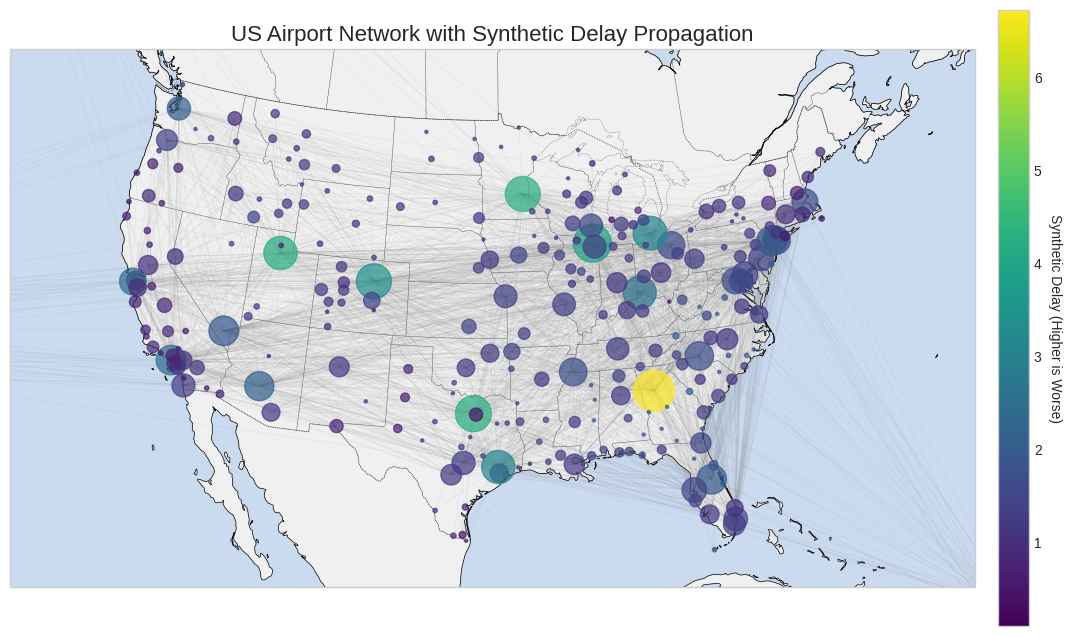

In [3]:
plot_airport_network_map(airport_network=airport_network)

In [4]:
x_train: np.ndarray
x_test: np.ndarray
y_train: np.ndarray
y_test: np.ndarray
train_indices: np.ndarray
test_indices: np.ndarray
original_idx_to_node_map: Dict[int, Optional[str]]

(
    x_train,
    x_test,
    y_train,
    y_test,
    train_indices,
    test_indices,
    original_idx_to_node_map,
) = prepare_ml_data(
    df_features=df_features,
    x_features=x_features,
    y_delay=y_delay,
    test_size=0.2,
)

Creating original index-to-node map...
Index to node map created for 305 airports.
Splitting data into train/test sets...
Training samples: 244, Test samples: 61
Scaling non positional features...


🎨 Visualizing kernel similarity from 'HOU'...
Calling kernel function to get similarity scores...
Drawing edges...
Projecting node coordinates...


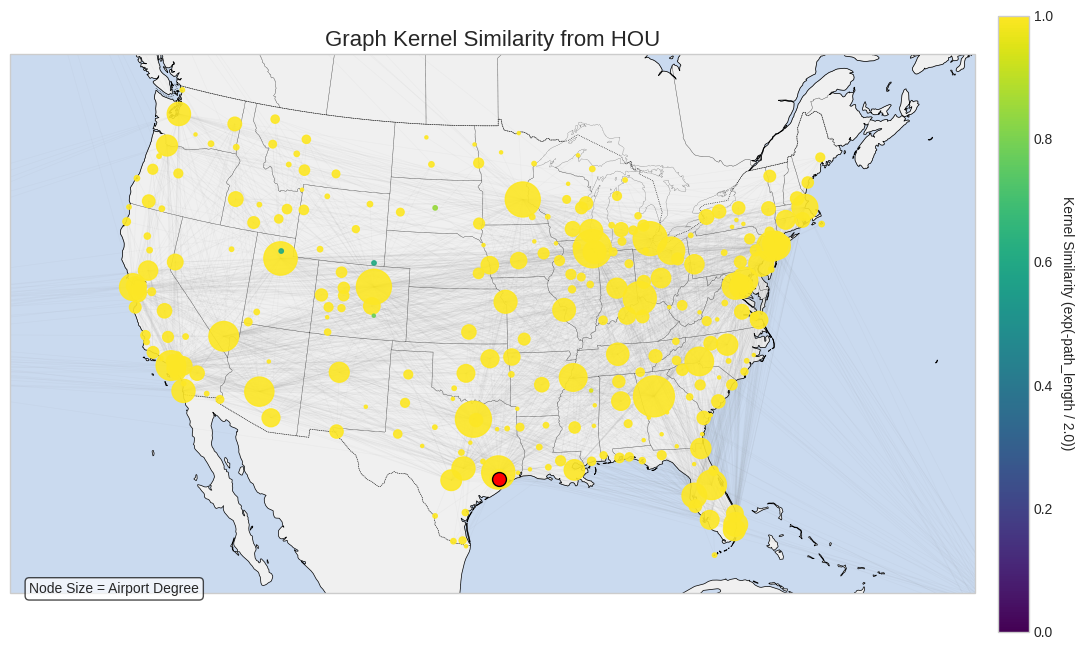

In [5]:
plot_graph_kernel_similarity(
    airport_network=airport_network,
    reference_node_id="HOU",
    graph_distance_scale=2.0,
    original_idx_to_node_map=original_idx_to_node_map,
)

🎨 Visualizing kernel similarity from 'ATL'...
Calling kernel function to get similarity scores...
Drawing edges...
Projecting node coordinates...


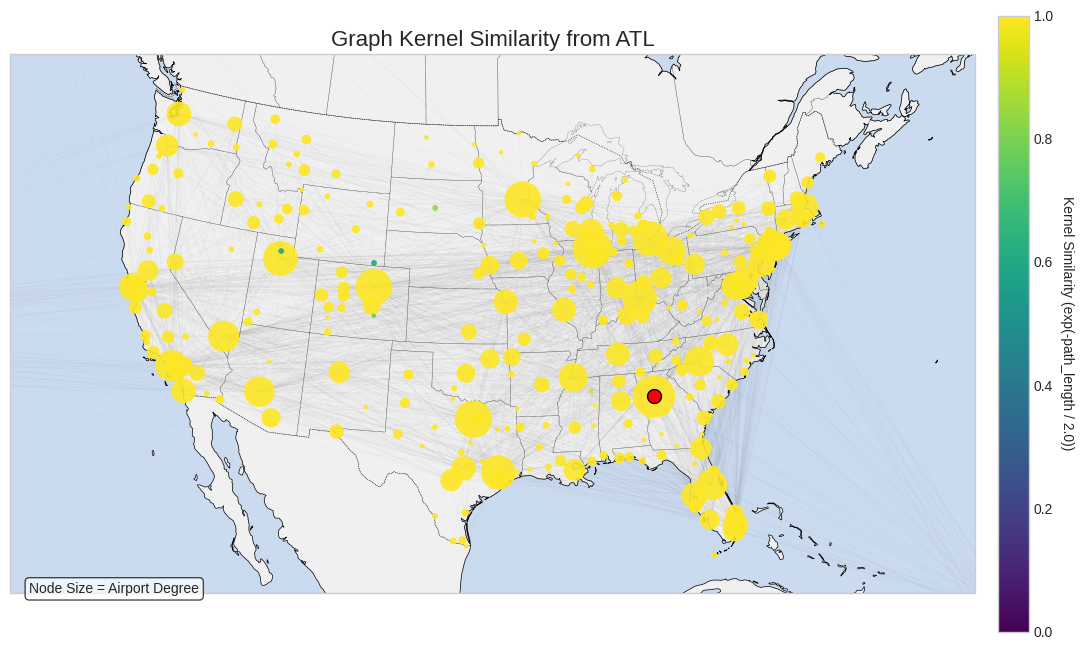

In [6]:
plot_graph_kernel_similarity(
    airport_network=airport_network,
    reference_node_id="ATL",
    graph_distance_scale=2.0,
    original_idx_to_node_map=original_idx_to_node_map,
)

In [7]:
cv: int = 10
n_jobs: int = -1

In [8]:
linear_param_grid: Dict[str, List[Any]] = {
    "fit_intercept": [True, False],
    "positive": [False, True],  # enforce non-negative coefficients
}


results_linear: GridSearchCV = cv_linear(
    x_train=x_train,
    y_train=y_train,
    param_grid=linear_param_grid,
    cv=cv,
    n_jobs=n_jobs,
)

results_linear.best_params_

🔎 Grid searching LinearRegression...
Fitting 10 folds for each of 4 candidates, totalling 40 fits


{'fit_intercept': True, 'positive': True}

In [9]:
rf_param_grid: List[Dict[str, Any]] = [
    {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20],
        "max_features": [1.0, "sqrt"],
        "min_samples_leaf": [1, 2, 4],
    }
]

results_rf: GridSearchCV = cv_random_forest(
    x_train=x_train, y_train=y_train, param_grid=rf_param_grid, cv=cv, n_jobs=n_jobs
)

results_rf.best_params_

🔎 Grid searching RandomForestRegressor...
Fitting 10 folds for each of 54 candidates, totalling 540 fits


{'max_depth': 20,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'n_estimators': 100}

In [10]:
# Standard LPR
size_neighborhood: List[int] = list(range(11, 205, 4))
degree: List[int] = [1]

kp: List[List[Callable]] = [
    [tricube_normalized_metric],
]

lpr_param_grid: List[Dict[str, List[Any]]] = [
    {
        "size_neighborhood": size_neighborhood,
        "degree": degree,
        "kp": kp,
        "kr": ["none"],
        "metric_x": ["mahalanobis"],
    },
]


results_lpr: GridSearchCV = cv_lpr(
    x_train=x_train,
    y_train=y_train,
    param_grid=lpr_param_grid,
    cv=cv,
    n_jobs=n_jobs,
)

results_lpr.best_params_

🔎 Grid searching LPR (using IndexAwareWrapper)...
Fitting 10 folds for each of 49 candidates, totalling 490 fits


{'degree': 1,
 'kp': [<function rsklpr.kernels.tricube_normalized_metric(_: numpy.ndarray, __: numpy.ndarray, u: numpy.ndarray, ___: int, ____: numpy.ndarray) -> numpy.ndarray>],
 'kr': 'none',
 'metric_x': 'mahalanobis',
 'size_neighborhood': 123}

In [11]:
graph_lpr_param_grid: List[Dict[str, Any]] = [
    {
        "size_neighborhood": list(range(11, 205, 4)),
        "degree": [1],
        "kp": [
            [tricube_normalized_metric, "GRAPH_KERNEL_PLACEHOLDER"],
        ],
        "kr": ["conden"],
        "metric_x": ["mahalanobis"],
        "graph_distance_scale": np.linspace(0.1, 3.0, num=29),
    },
]

# 2. Call cv_graph_lpr with *all* required arguments
results_graph_lpr: GridSearchCV = cv_graph_lpr(
    x_train=x_train,
    y_train=y_train,
    train_indices=train_indices,  # The train indices from train_test_split!
    airport_network=airport_network,
    original_idx_to_node_map=original_idx_to_node_map,
    param_grid=graph_lpr_param_grid,
    cv=cv,
    n_jobs=n_jobs,
)

print(results_graph_lpr.best_params_)

🔎 Grid searching Graph LPR (using IndexAwareWrapper)...
Fitting 10 folds for each of 1421 candidates, totalling 14210 fits


KeyboardInterrupt: 

In [ ]:
display_model_results(
    grid_search_results={
        "linear": results_linear,
        "rf": results_rf,
        "lpr": results_lpr,
        "graph_lpr": results_graph_lpr,
    },
    x_test=x_test,
    y_test=y_test,
    test_indices=test_indices,
)